In [56]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from tqdm import tqdm

In [57]:
ns = [20, 50, 100]
thetas = [0, 4, 0, 4]
sigmas = [1, 1, 2, 2]
T = 10**4

In [58]:
import os 

BASE_DIR = '../plots/zad4b'
os.makedirs(BASE_DIR, exist_ok=True)
plot_dist_dir = os.path.join(BASE_DIR, 'wykresy_rozkładow')
os.makedirs(plot_dist_dir, exist_ok=True)
plot_metrics_dir = os.path.join(BASE_DIR, 'wykresy_metryk')
os.makedirs(plot_metrics_dir, exist_ok=True)
stats_dir = os.path.join(BASE_DIR, 'statystyki_metryki')
os.makedirs(stats_dir, exist_ok=True)
print(f"Przygotowano foldery w: {BASE_DIR}")

Przygotowano foldery w: ../plots/zad4b


In [59]:
def gen_sample(n, theta, sigma):
    return np.random.lognormal(mean=theta, sigma=sigma, size=n)

In [60]:
def estimator_theta(xs):
    return np.mean(np.log(xs))

In [61]:
def estimator_mom(xs, sigma): 
    m1 = np.mean(xs)
    theta_hat = np.log(m1) - 0.5 * sigma**2
    return theta_hat

In [62]:
results = {n: {} for n in ns}
metrics = {n: {} for n in ns}

for n in ns:
    for theta, sigma in zip(thetas, sigmas):
        mle_ests = []
        mom_ests = []

        for _ in tqdm(range(T), desc=f"n={n}, theta={theta}, sigma={sigma}"):
            sample = gen_sample(n, theta, sigma)
            mle_ests.append(estimator_theta(sample))
            mom_ests.append(estimator_mom(sample, sigma))

        mle_ests = np.array(mle_ests)
        mom_ests = np.array(mom_ests)

        results[n][(theta, sigma)] = {
            'mle': mle_ests,
            'mom': mom_ests
        }

        mle_clean = mle_ests[~np.isnan(mle_ests)]
        mom_clean = mom_ests[~np.isnan(mom_ests)]

        metrics[n][(theta, sigma)] = {
            'mle': {
                'bias': np.mean(mle_clean) - theta,
                'var': np.var(mle_clean),
                'mse': np.mean((mle_clean - theta)**2)
            },
            'mom': {
                'bias': np.mean(mom_clean) - theta,
                'var': np.var(mom_clean),
                'mse': np.mean((mom_clean - theta)**2)
            }
        }


n=20, theta=0, sigma=1:   0%|          | 0/10000 [00:00<?, ?it/s]

n=100, theta=4, sigma=2: 100%|██████████| 10000/10000 [00:00<00:00, 118673.24it/s]


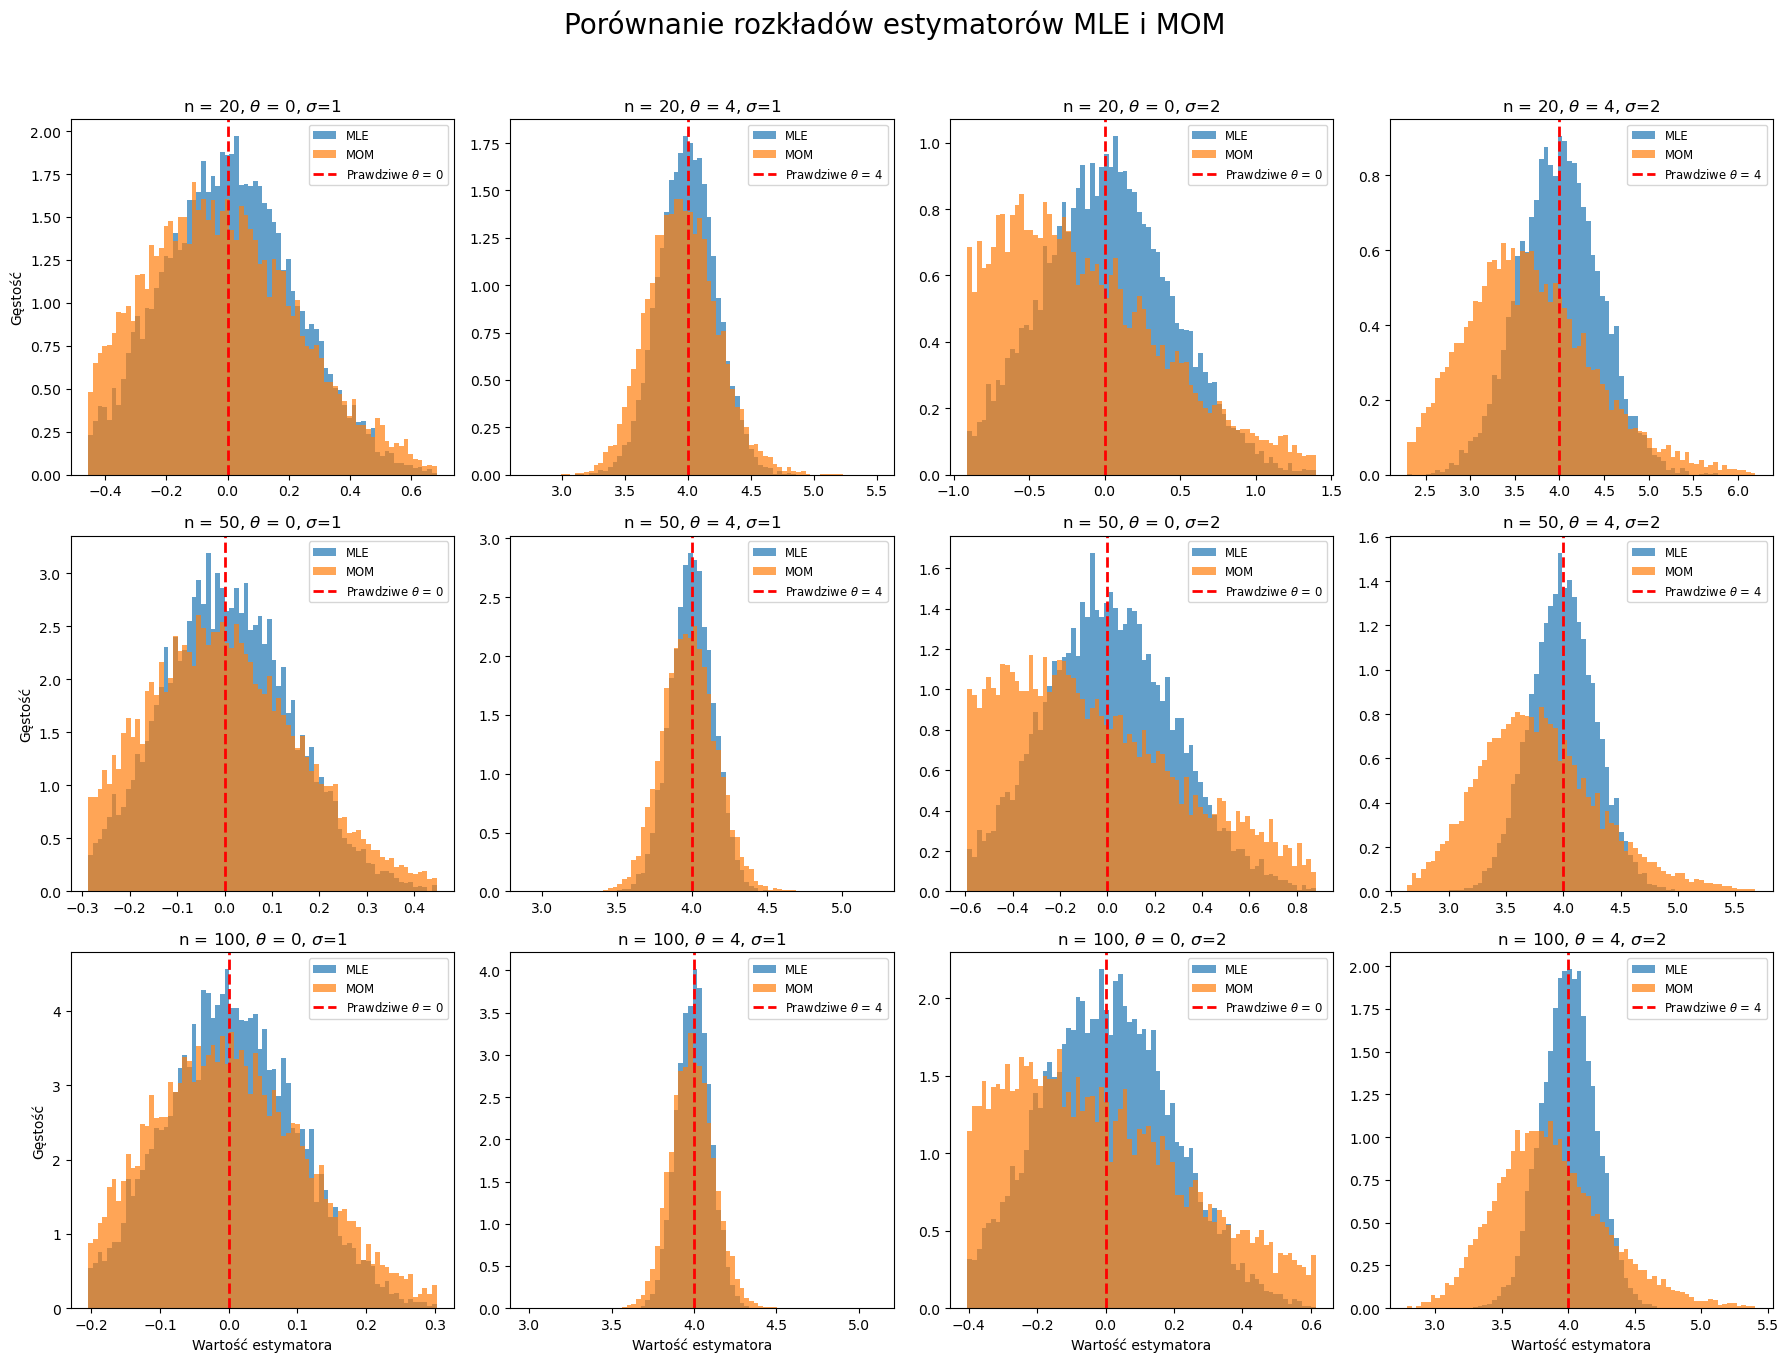

In [63]:
fig, axes = plt.subplots(len(ns), len(thetas), figsize=(18, 14), sharex=False)
fig.suptitle('Porównanie rozkładów estymatorów MLE i MOM', fontsize=20, y=1)

for i, n in enumerate(ns):
    for j, (theta, sigma) in enumerate(zip(thetas, sigmas)):
        ax = axes[i, j]

        # poprawiony klucz!
        mle_ests = results[n][(theta, sigma)]['mle']
        mom_ests = results[n][(theta, sigma)]['mom']

        mle_clean = mle_ests[~np.isnan(mle_ests)]
        mom_clean = mom_ests[~np.isnan(mom_ests)]

        q_mle_low = np.percentile(mle_clean, 0.5)
        q_mle_high = np.percentile(mle_clean, 99.5)
        plot_range = (q_mle_low * 0.8, q_mle_high * 1.2)

        bins = np.linspace(plot_range[0], plot_range[1], 75)

        ax.hist(mle_clean, bins=bins, density=True, alpha=0.7, label='MLE')
        ax.hist(mom_clean, bins=bins, density=True, alpha=0.7, label='MOM')

        ax.axvline(theta, color='red', linestyle='--', linewidth=2, label=f'Prawdziwe $\\theta$ = {theta}')

        ax.set_title(f'n = {n}, $\\theta$ = {theta}, $\\sigma$={sigma}')
        ax.legend(fontsize='small')

        if i == len(ns) - 1:
            ax.set_xlabel('Wartość estymatora')
        if j == 0:
            ax.set_ylabel('Gęstość')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
filename = os.path.join(plot_dist_dir, 'histograms_mle_mom_comparison.png')
plt.savefig(filename)
plt.show()
plt.close()


In [67]:
import pandas as pd

theta_sigma_pairs = list(zip(thetas, sigmas))

bias_rows = []
var_rows = []
mse_rows = []

for (theta, sigma) in theta_sigma_pairs:
    row_bias = {'theta': theta, 'sigma': sigma}
    row_var  = {'theta': theta, 'sigma': sigma}
    row_mse  = {'theta': theta, 'sigma': sigma}

    for n in ns:
        row_bias[f'MLE{n}'] = metrics[n][(theta, sigma)]['mle']['bias']
        row_bias[f'MOM{n}'] = metrics[n][(theta, sigma)]['mom']['bias']

        row_var[f'MLE{n}'] = metrics[n][(theta, sigma)]['mle']['var']
        row_var[f'MOM{n}'] = metrics[n][(theta, sigma)]['mom']['var']

        row_mse[f'MLE{n}'] = metrics[n][(theta, sigma)]['mle']['mse']
        row_mse[f'MOM{n}'] = metrics[n][(theta, sigma)]['mom']['mse']

    bias_rows.append(row_bias)
    var_rows.append(row_var)
    mse_rows.append(row_mse)

df_bias = pd.DataFrame(bias_rows).round(3)
df_var  = pd.DataFrame(var_rows).round(3)
df_mse  = pd.DataFrame(mse_rows).round(3)

print("TABELA: BIAS")
display(df_bias)

print("\nTABELA: VARIANCE")
display(df_var)

print("\nTABELA: MSE")
display(df_mse)

df_bias.to_csv(os.path.join(stats_dir, 'bias_table.csv'), index=False)
df_var.to_csv(os.path.join(stats_dir, 'variance_table.csv'), index=False)
df_mse.to_csv(os.path.join(stats_dir, 'mse_table.csv'), index=False)

print(f"\nZapisano tabelki w folderze: {stats_dir}")


TABELA: BIAS


,theta,sigma,MLE20,MOM20,MLE50,MOM50,MLE100,MOM100
0,0,1,-0.000,-0.043,-0.000,-0.018,0.001,-0.008
1,4,1,-0.002,-0.041,0.000,-0.018,-0.001,-0.009
2,0,2,0.002,-0.349,-0.003,-0.197,-0.002,-0.117
3,4,2,-0.003,-0.348,-0.002,-0.201,0.000,-0.119



TABELA: VARIANCE


,theta,sigma,MLE20,MOM20,MLE50,MOM50,MLE100,MOM100
0,0,1,0.050,0.076,0.020,0.032,0.01,0.016
1,4,1,0.050,0.075,0.020,0.032,0.01,0.017
2,0,2,0.198,0.556,0.081,0.306,0.04,0.200
3,4,2,0.204,0.581,0.081,0.316,0.04,0.195



TABELA: MSE


,theta,sigma,MLE20,MOM20,MLE50,MOM50,MLE100,MOM100
0,0,1,0.050,0.078,0.020,0.032,0.01,0.016
1,4,1,0.050,0.077,0.020,0.032,0.01,0.017
2,0,2,0.198,0.677,0.081,0.345,0.04,0.213
3,4,2,0.204,0.702,0.081,0.356,0.04,0.209



Zapisano tabelki w folderze: ../plots/zad4b/statystyki_metryki
